

## Task 1: Supervised ML Classification – Air Quality Index (AQI) Category Prediction

In this task, a supervised machine learning classification model is developed to predict daily Air Quality Index (AQI) categories using Pakistan’s air quality dataset. The model classifies air conditions into standard categories such as Good, Moderate, Unhealthy, and Hazardous. The complete machine learning pipeline is followed, including data preprocessing, feature selection, model training, evaluation, and performance analysis.





In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('concatenated_dataset_Aug_2021_to_July_2024.csv')
print(df.head())

         datetime  main_aqi  components_co  components_no  components_no2  \
0  8/24/2021 0:00         5        1014.71           0.00           17.14   
1  8/24/2021 1:00         5        1054.76           0.01           19.36   
2  8/24/2021 2:00         5        1295.09           1.40           30.16   
3  8/24/2021 3:00         5        1682.28           9.16           41.13   
4  8/24/2021 4:00         5        1321.79           4.81           32.56   

   components_o3  components_so2  components_pm2_5  components_pm10  \
0          35.76            6.44             59.59            66.81   
1          32.19            6.68             66.96            74.88   
2          22.89            8.70             79.88            89.90   
3          28.25           12.99             98.91           111.25   
4          91.55           27.90             89.59            97.95   

   components_nh3  temperature_2m  relative_humidity_2m  dew_point_2m  \
0            5.95            28.1    

In [2]:
def map_aqi(x):
    if x == 1: return 'Good'
    elif x == 2: return 'Moderate'
    elif x <= 4: return 'Unhealthy'
    else: return 'Hazardous'

df['AQI_Category'] = df['main_aqi'].apply(map_aqi)
# Drop non-predictive columns (datetime) and the original target
df_clean = df.drop(columns=['datetime', 'main_aqi']).dropna()

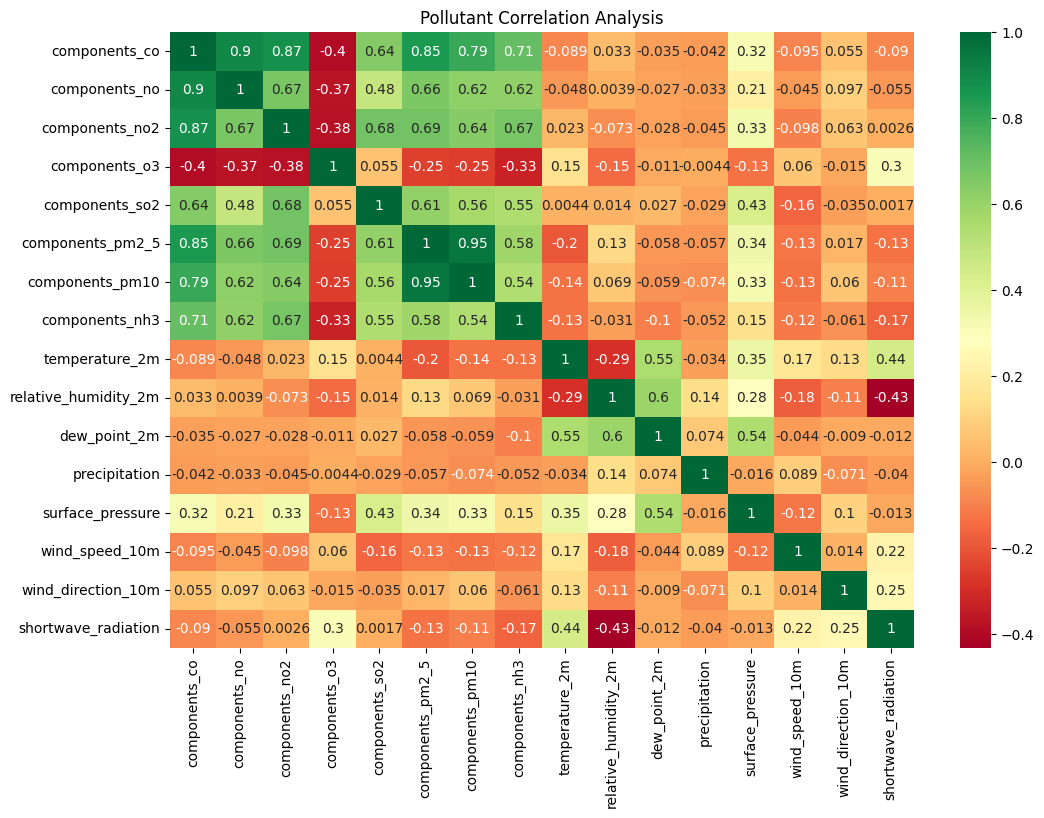

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap to see which pollutants drive AQI
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.select_dtypes(include=[np.number]).corr(), annot=True, cmap='RdYlGn')
plt.title("Pollutant Correlation Analysis")
plt.show()

In [4]:
# Feature Engineering: The interaction between PM2.5 and Humidity often triggers 'Hazardous' alerts in Pakistan
df_clean['PM_Hum_Interaction'] = df_clean['components_pm2_5'] * df_clean['relative_humidity_2m']
X = df_clean.drop(columns=['AQI_Category'])
y = df_clean['AQI_Category']

In [5]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced')
}

for name, model in models.items():
    model.fit(X_train, y_train)

In [8]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Results for Random Forest (typically the best)
y_pred = models["Random Forest"].predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        Good       0.95      0.96      0.96       422
   Hazardous       0.97      0.98      0.97     14841
    Moderate       0.95      0.94      0.95      2949
   Unhealthy       0.96      0.96      0.96     12572

    accuracy                           0.97     30784
   macro avg       0.96      0.96      0.96     30784
weighted avg       0.97      0.97      0.97     30784



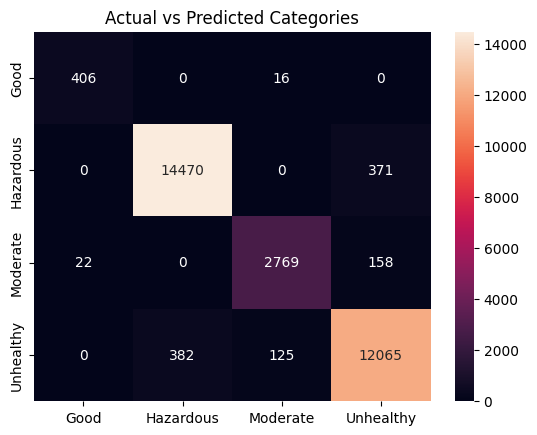

In [9]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Actual vs Predicted Categories")
plt.show()